### London Climate & Weather Analysis

#### Project Overview & Business Context
Fluctuations in ambient temperature and climate shifts directly affect municipal power demand, agricultural yields, and commercial supply chain operations. Accurate daily temperature forecasting enables energy utilities to optimize generation dispatch, balance electrical loads, and assist local infrastructure planning.

This project analyzes over 40 years of continuous meteorological observations recorded in London between 1979 and 2020. Using a combination of time-series feature engineering, correlation analysis, and supervised machine learning, I benchmark multiple regression algorithms (**Linear Regression**, **Decision Tree Regressor**, and **Gradient Boosting Regressor**) across hyperparameter spaces. All model runs, metrics, parameters, and serialized artifacts are systematically tracked and managed via **MLflow**.

#### Data Dictionary
| Variable | Description | Measurement Unit | Data Type |
| :--- | :--- | :--- | :--- |
| `date` | Observation date recorded as integer (`YYYYMMDD`) | Date integer | `int64` |
| `cloud_cover` | Cloud coverage | Oktas (0–9 scale) | `float64` |
| `sunshine` | Duration of sunshine | Hours (hrs) | `float64` |
| `global_radiation` | Solar irradiance | Watt per square meter (W/m²) | `float64` |
| `max_temp` | Maximum recorded daily temperature | Degrees Celsius (°C) | `float64` |
| `mean_temp` | Mean daily temperature (**Target Variable**) | Degrees Celsius (°C) | `float64` |
| `min_temp` | Minimum recorded daily temperature | Degrees Celsius (°C) | `float64` |
| `precipitation` | Daily rainfall accumulation | Millimeters (mm) | `float64` |
| `pressure` | Atmospheric pressure at sea level | Pascals (Pa) | `float64` |
| `snow_depth` | Ground snow accumulation | Centimeters (cm) | `float64` |

#### Environment Setup

In [1]:
# Run this cell to import the modules you require
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Read in the data
weather = pd.read_csv("london_weather.csv")

#### Data Integrity & Structural Inspection

In [2]:
# Use info() to understand column names, data types, and number of non-null values
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15341 entries, 0 to 15340
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              15341 non-null  int64  
 1   cloud_cover       15322 non-null  float64
 2   sunshine          15341 non-null  float64
 3   global_radiation  15322 non-null  float64
 4   max_temp          15335 non-null  float64
 5   mean_temp         15305 non-null  float64
 6   min_temp          15339 non-null  float64
 7   precipitation     15335 non-null  float64
 8   pressure          15337 non-null  float64
 9   snow_depth        13900 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 1.2 MB


#### Summary Statistics

In [3]:
# Use describe to understand distribution of values within each numeric column
weather.describe()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
count,1.534100e+04,15322.000000,15341.000000,15322.000000,15335.000000,15305.000000,15339.000000,15335.000000,15337.000000,13900.000000
mean,1.999567e+07,5.268242,4.350238,118.756951,15.388777,11.475511,7.559867,1.668634,101536.605594,0.037986
std,1.212176e+05,2.070072,4.028339,88.898272,6.554754,5.729709,5.326756,3.738540,1049.722604,0.545633
min,1.979010e+07,0.000000,0.000000,8.000000,-6.200000,-7.600000,-11.800000,0.000000,95960.000000,0.000000
25%,1.989070e+07,4.000000,0.500000,41.000000,10.500000,7.000000,3.500000,0.000000,100920.000000,0.000000
50%,2.000010e+07,6.000000,3.500000,95.000000,15.000000,11.400000,7.800000,0.000000,101620.000000,0.000000
75%,2.010070e+07,7.000000,7.200000,186.000000,20.300000,16.000000,11.800000,1.600000,102240.000000,0.000000
max,2.020123e+07,9.000000,16.000000,402.000000,37.900000,29.000000,22.300000,61.800000,104820.000000,22.000000


In [4]:
# Look at the first 5 rows of the dataframe
weather.head()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,19790101,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,19790102,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,19790103,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,19790104,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,19790105,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


#### Data Cleaning & Feature Engineering
The raw `date` column is encoded as a discrete integer (`int64`), preventing direct temporal operations. I convert this into a standard `datetime64` format and extract cyclical calendar attributes (`year` and `month`) to enable macro-trend and seasonality analysis.

In [5]:
# Convert the integer to datetime
weather['date'] = pd.to_datetime(weather['date'].astype(str), format='%Y%m%d')


In [6]:
# Extract more information from the date column
weather['year'] = weather['date'].dt.year

weather['month'] = weather['date'].dt.month

#### Exploratory Data Analysis

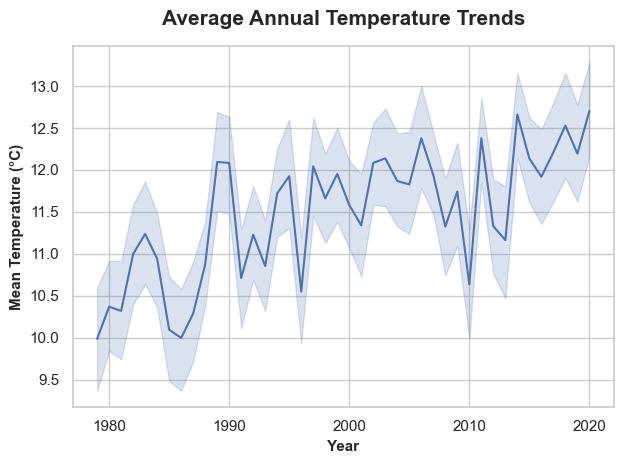

<Figure size 640x480 with 0 Axes>

In [7]:
# Visualize temperature over years
sns.set_theme(style="whitegrid")  


sns.lineplot(
    data=weather,
    x='year',
    y='mean_temp',
)

plt.title('Average Annual Temperature Trends', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=11, fontweight='semibold')
plt.ylabel('Mean Temperature (°C)', fontsize=11, fontweight='semibold')

plt.tight_layout()
plt.show()

plt.savefig('temperature_by_year.png')

**Key Trend Observations:**
- The line chart shows a pronounced upward trend, rising from ~10.0°C in the early 1980s to consistently averaging 11.5°C–12.5°C post-2000.
- Colder anomalies in the mid-1980s and 2010 contrast with warm peaks observed in 2003, 2006, 2014, and 2018–2020.

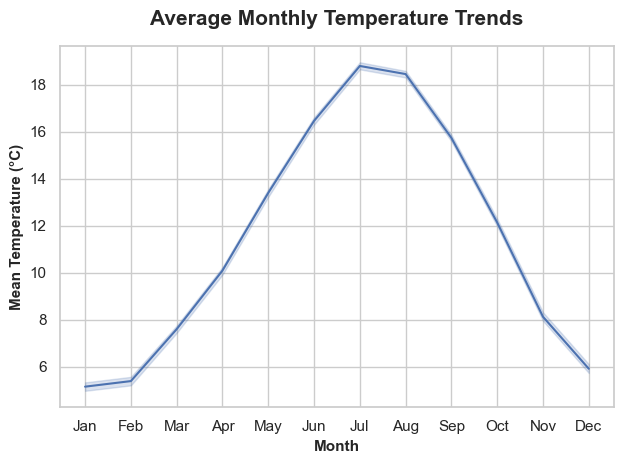

<Figure size 640x480 with 0 Axes>

In [8]:
# Visualize temperature over months
sns.set_theme(style="whitegrid")  


sns.lineplot(
    data=weather,
    x='month',
    y='mean_temp',
)

plt.title('Average Monthly Temperature Trends', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=11, fontweight='semibold')
plt.ylabel('Mean Temperature (°C)', fontsize=11, fontweight='semibold')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.tight_layout()
plt.show()

plt.savefig('temperature_by_month.png')

**Key Seasonal Observations:**
- London follows a classic curve characteristic of a temperate seasonal climate.
- Winter minimums occur in January and February (~5.2°C to 5.5°C), while summer peaks occur in July and August (~18.5°C to 18.8°C).

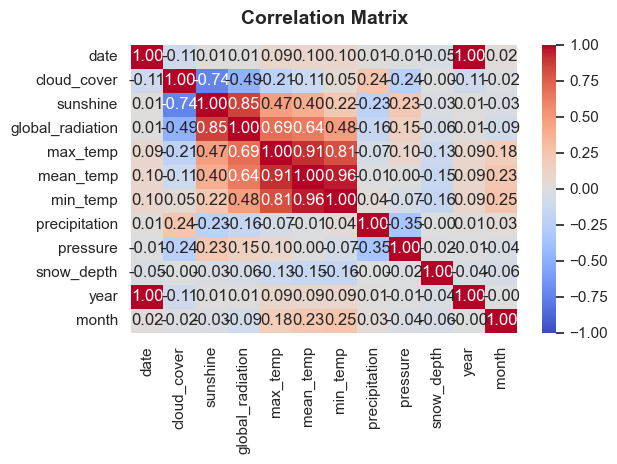

<Figure size 640x480 with 0 Axes>

In [9]:
# Look into correlations between variables
corr_matrix = weather.corr()

sns.heatmap(
    data=corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1, vmax=1
)

plt.title('Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

plt.savefig('correlation_matrix.png')

#### Feature Selection
From the correlation matrix:
- `max_temp` ($r = 0.91$) and `min_temp` ($r = 0.96$) are near-perfect linear correlates of `mean_temp`. Including same-day temperature extremes would introduce severe target leakage in an operational forecasting scenario where `max_temp` and `min_temp` are not known in advance.
- Feature space is restricted only to observable drivers: `month`, `cloud_cover`, `sunshine`, `precipitation`, `pressure`, `global_radiation`, and `snow_depth`.
- Rows with missing target values (`mean_temp`) are dropped to ensure models are trained solely on verifiable observations.

In [10]:
# Select features most correlated with mean temperature
feature_selection = ['month', 'cloud_cover', 'sunshine', 'precipitation', 'pressure', 'global_radiation', 'snow_depth']

# Drop non available values for the target variable
weather = weather.dropna(subset=['mean_temp'])

# Create feature set and target set
X = weather[feature_selection]
y = weather['mean_temp']

#### Data Preprocessing

1. **Train/Test Split:** An 80/20 train/test split partitions the dataset into independent training and validation spaces.
2. **Missing Data Imputation:** Skewed features (`snow_depth`, `precipitation`) are imputed using a median strategy via `SimpleImputer`, fitted strictly on the training set.
3. **Standardization:** `StandardScaler` was used to standardize features to zero mean and unit variance, fitting on `X_train` and transforming `X_test`.

In [11]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Use simple imputer to deal with missing values
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Use standard scaler to normalize values
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

#### Model Training & Evaluation
I evaluated three model families across different hyperparameter constraints (`max_depth` $\in [1, 2, 10]$):
- **Baseline:** Linear Regression (`LinearRegression`)
- **Non-Parametric Tree:** Decision Tree Regressor (`DecisionTreeRegressor`)
- **Ensemble:** Gradient Boosting Regressor (`GradientBoostingRegressor`)

For every run, MLflow tracks the parameters (`max_depth`) and evaluation metrics (test RMSE across all three models).

In [ ]:
# Build a list of parameters to loop
for idx, depth in enumerate([1, 2, 10]):
    run_name = f"run_{idx}"
    with mlflow.start_run(run_name=run_name):
        lr_model = LinearRegression()
        dt_model = DecisionTreeRegressor(max_depth=depth, random_state=42)
        gbt_model = GradientBoostingRegressor(max_depth=depth, random_state=42)
        
        lr_model.fit(X_train_scaled, y_train)
        dt_model.fit(X_train_scaled, y_train)
        gbt_model.fit(X_train_scaled, y_train)
        
        mlflow.sklearn.log_model(lr_model, f"linear_regression")
        mlflow.sklearn.log_model(dt_model, f"decision_tree_depth_{depth}")
        mlflow.sklearn.log_model(gbt_model, f"gradient_boosting_depth_{depth}")
        
        mlflow.log_param("max_depth", depth)
        
        lr_predictions = lr_model.predict(X_test_scaled)
        lr_rmse = mean_squared_error(y_test, lr_predictions, squared=False)
        mlflow.log_metric("rmse_lr", lr_rmse)
        
        dt_predictions = dt_model.predict(X_test_scaled)
        dt_rmse = mean_squared_error(y_test, dt_predictions, squared=False)
        mlflow.log_metric("rmse_dt", dt_rmse)
        
        gbt_predictions = gbt_model.predict(X_test_scaled)
        gbt_rmse = mean_squared_error(y_test, gbt_predictions, squared=False)
        mlflow.log_metric("rmse_gbt", gbt_rmse)
        

#### Experiment Results
Querying the MLflow Tracking Server to retrieve, inspect, and benchmark all recorded model runs based on out-of-sample Root Mean Squared Error (RMSE).

In [ ]:
# Fetch all logged data for the experiment and store it in a variable
experiment_results = mlflow.search_runs()

# View a preview of tracked parameters and RMSE metrics
experiment_results.head(3)

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.rmse_gbt,metrics.rmse_dt,metrics.rmse_lr,params.max_depth,tags.mlflow.log-model.history,tags.mlflow.source.name,tags.mlflow.runName,tags.mlflow.source.type,tags.mlflow.user
0,50b8a227959943ab9b625df060fd4be1,0,FINISHED,file:///work/files/workspace/mlruns/0/50b8a227...,2026-09-16 14:04:57.583000+00:00,2026-09-16 14:05:09.186000+00:00,2.809710,2.944269,3.655807,10,"[{""run_id"": ""50b8a227959943ab9b625df060fd4be1""...",/usr/lib/python3/dist-packages/python_kernel/k...,run_2,LOCAL,repl
1,552750433aa946c0aa6e1c9bf601cc90,0,FINISHED,file:///work/files/workspace/mlruns/0/55275043...,2026-09-16 14:04:48+00:00,2026-09-16 14:04:57.483000+00:00,2.800233,3.855133,3.655807,2,"[{""run_id"": ""552750433aa946c0aa6e1c9bf601cc90""...",/usr/lib/python3/dist-packages/python_kernel/k...,run_1,LOCAL,repl
2,ebe32aa7b8334c5d844becc87b2e9676,0,FINISHED,file:///work/files/workspace/mlruns/0/ebe32aa7...,2026-09-16 14:04:38.933000+00:00,2026-09-16 14:04:47.895000+00:00,3.028467,4.686188,3.655807,1,"[{""run_id"": ""ebe32aa7b8334c5d844becc87b2e9676""...",/usr/lib/python3/dist-packages/python_kernel/k...,run_0,LOCAL,repl


#### Performance Analysis

##### Model Comparison Leaderboard
From the logged MLflow runs, we observe the following performance breakdown on the held-out test set:

| Experiment Run | `max_depth` | Linear Regression RMSE (°C) | Decision Tree RMSE (°C) | Gradient Boosting RMSE (°C) |
| :--- | :---: | :---: | :---: | :---: |
| **`run_0`** | 1 | 3.6558 | 4.6862 | 3.0285 |
| **`run_1`** | 2 | 3.6558 | 3.8551 | **2.8002** |
| **`run_2`** | 10 | 3.6558 | 2.9443 | 2.8097 |

##### Core Findings:
1. **Champion Model:** **Gradient Boosting Regressor at `max_depth=2`** achieved the lowest overall test error with an **RMSE of 2.8002°C**, outperforming all other configurations.
2. **Depth Regularization vs. Overfitting:**
   - For individual **Decision Trees**, increasing tree depth from 1 to 10 significantly reduced test RMSE from 4.6862°C to 2.9443°C as the model captured non-linear interactions.
   - For **Gradient Boosting**, a shallow depth of 2 proved superior to depth 10 (2.8002°C vs. 2.8097°C), demonstrating that shallow weak learners mitigate overfitting in boosting ensembles.
3. **Baseline Comparison:** Unregularized **Linear Regression** served as a stable baseline with a constant RMSE of **3.6558°C** across runs, but failed to capture the non-linear seasonal interactions captured by tree-based ensembles.